# Anisotropy of the ADI Scheme

Comparing ADI sweep orders at |k|=40...
Y-first (peaks 90°,270°): Min=3.00e+00, Max=2.22e+02
X-first (peaks 0°,180°):  Min=8.68e+00, Max=3.51e+02
Saved adi_sweep_order_comparison.png
Saved angular_error_zoomed_y_first.png
Saved angular_error_zoomed_x_first.png
CONVERGENCE STUDY: ADI Method (Richardson Extrapolation)
Computing reference solution with dt_ref = 5.00e-07 (4000 steps)...

Grid: N=100, h=0.0100, CFL limit=2.50e-05
Initial condition: Gaussian (σ₀=0.05)
Target |k| for angular analysis: 40
Final time: t=0.002
Comparing to fine-dt reference (isolates temporal error)
------------------------------------------------------------
dt = 1.00e-06 (  0.0x CFL) | steps=2000 | L2=1.59e-08 | max_angular=5.35e-07 | anisotropy=3.91e-07
dt = 2.00e-06 (  0.1x CFL) | steps=1000 | L2=7.97e-08 | max_angular=2.68e-06 | anisotropy=1.95e-06
dt = 4.00e-06 (  0.2x CFL) | steps= 500 | L2=3.35e-07 | max_angular=1.12e-05 | anisotropy=8.21e-06
dt = 1.00e-05 (  0.4x CFL) | steps= 200 | L2=2.12e-06 | max_an

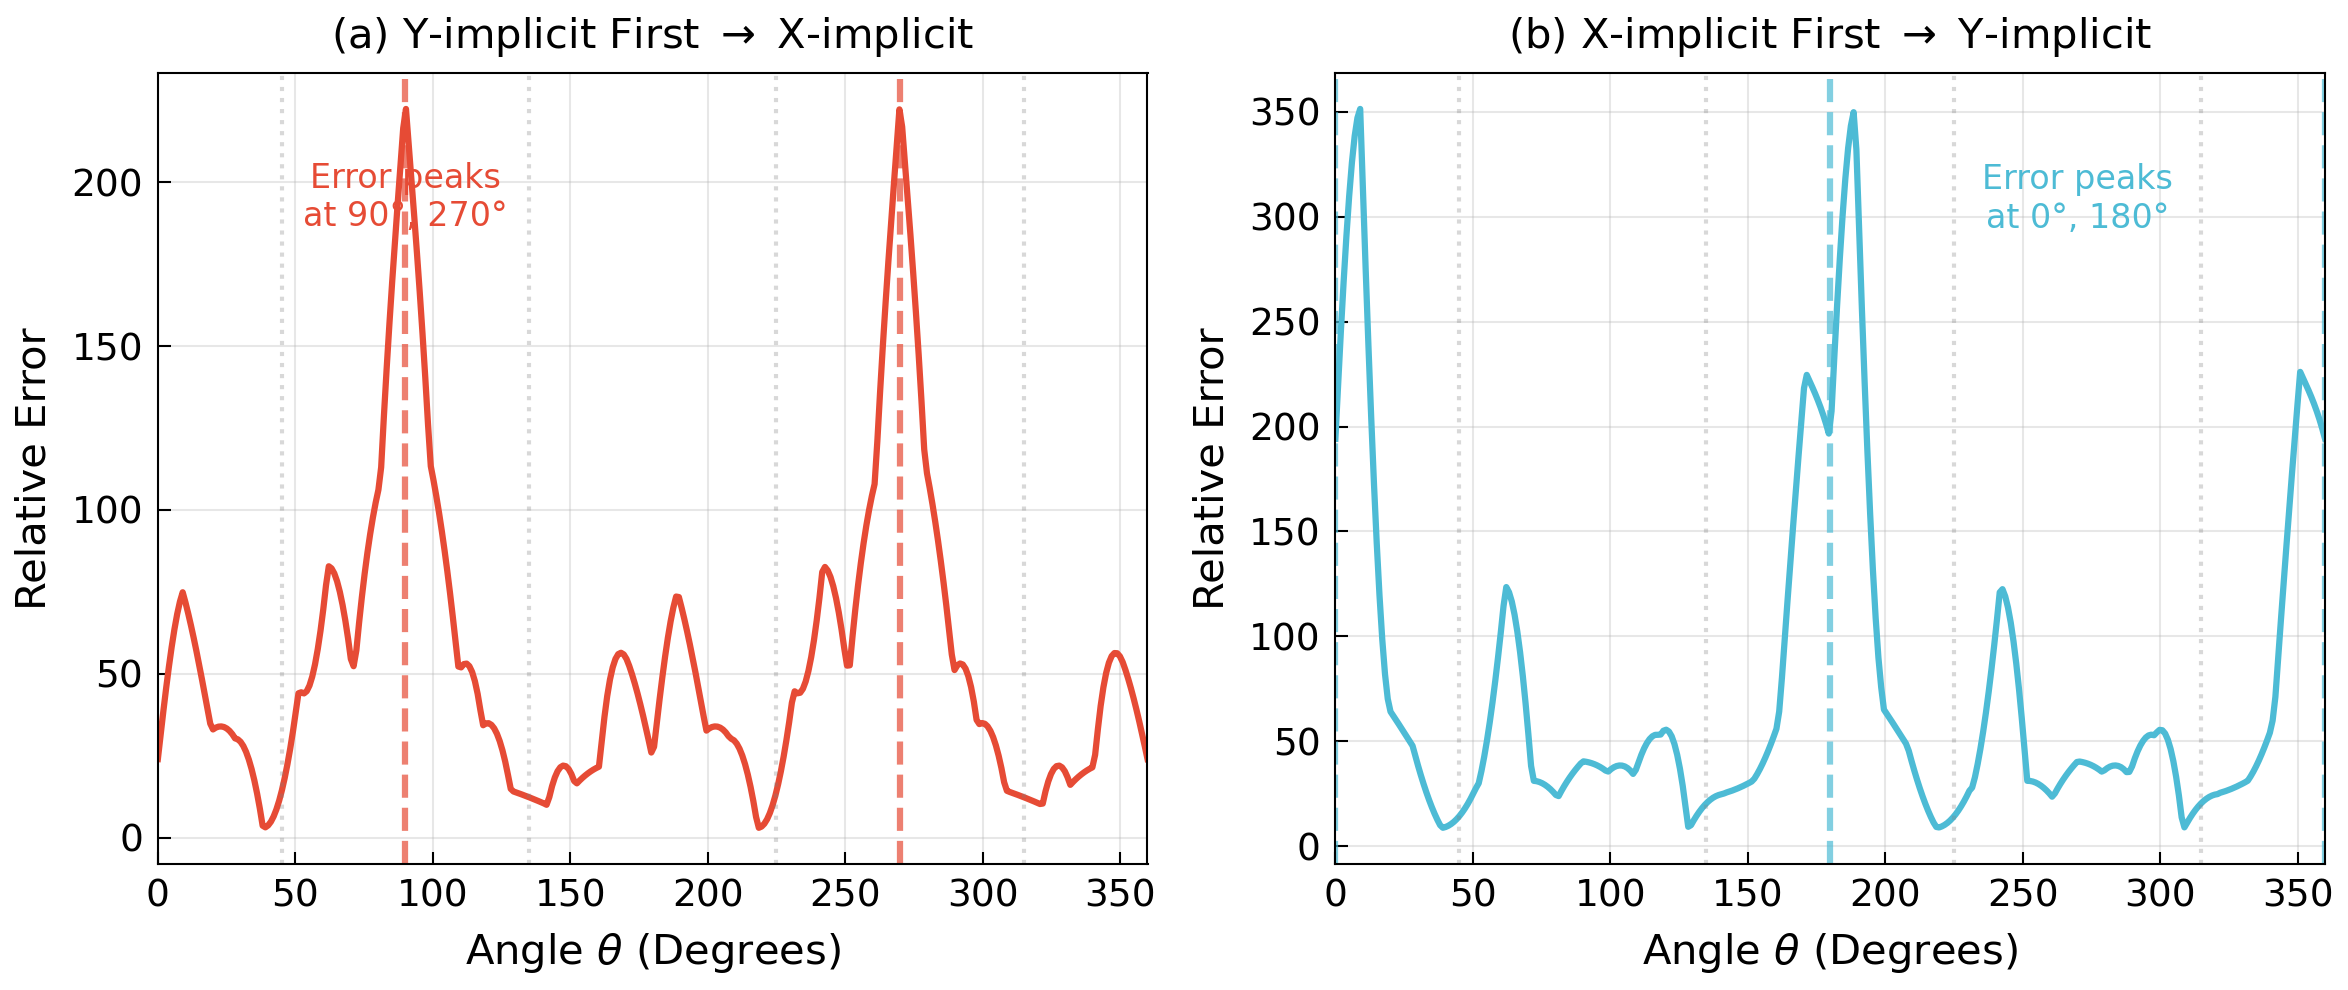

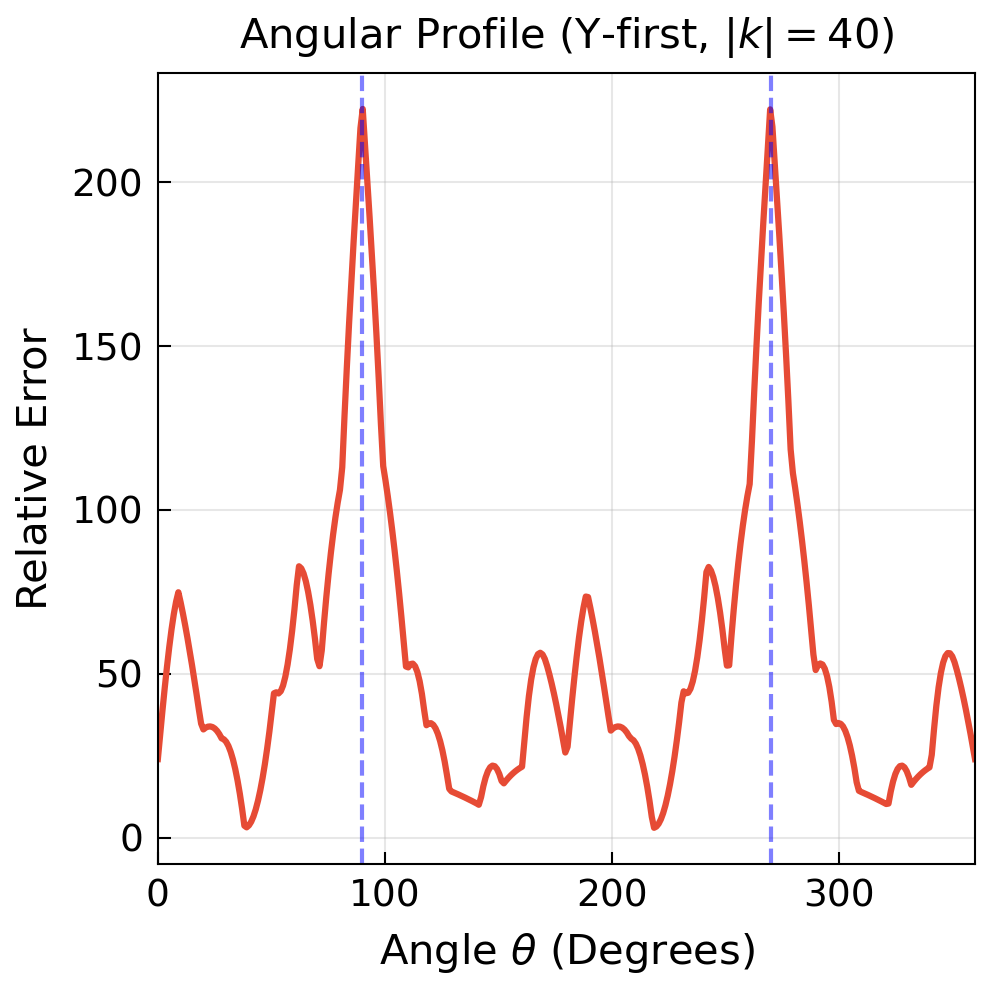

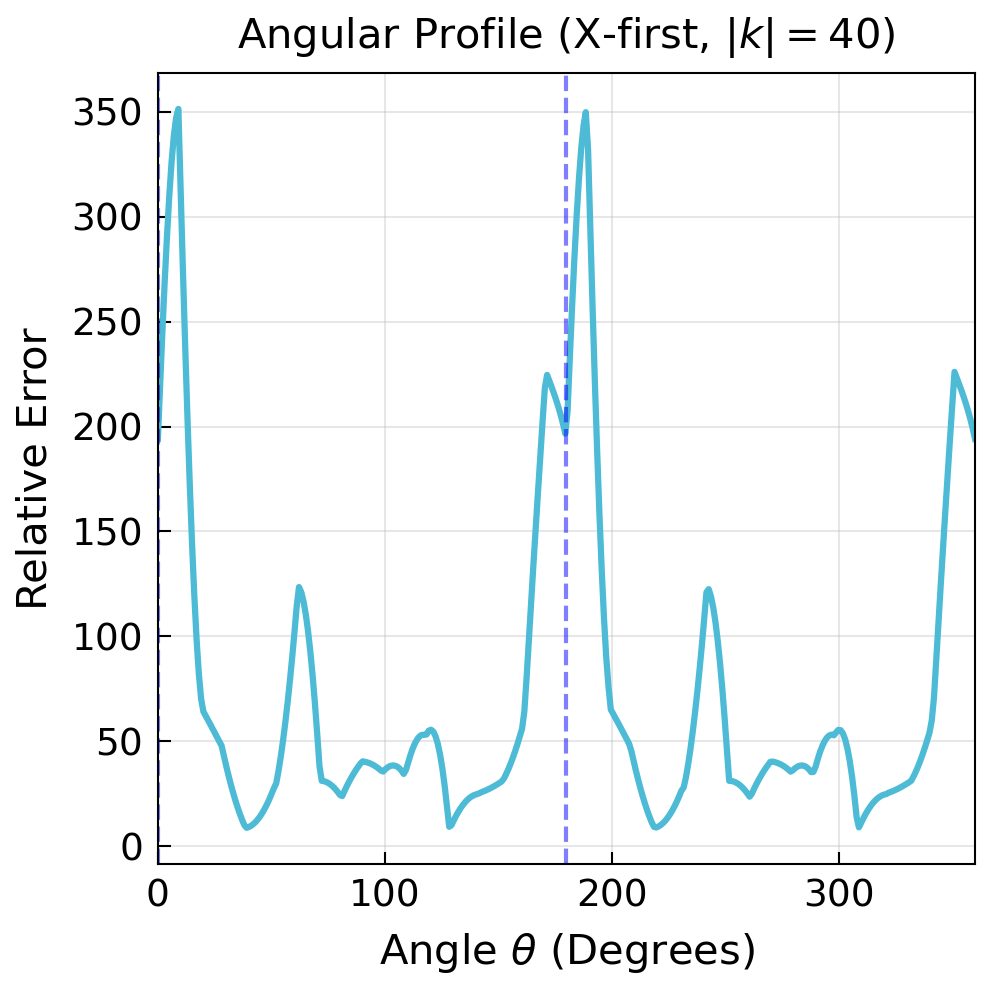

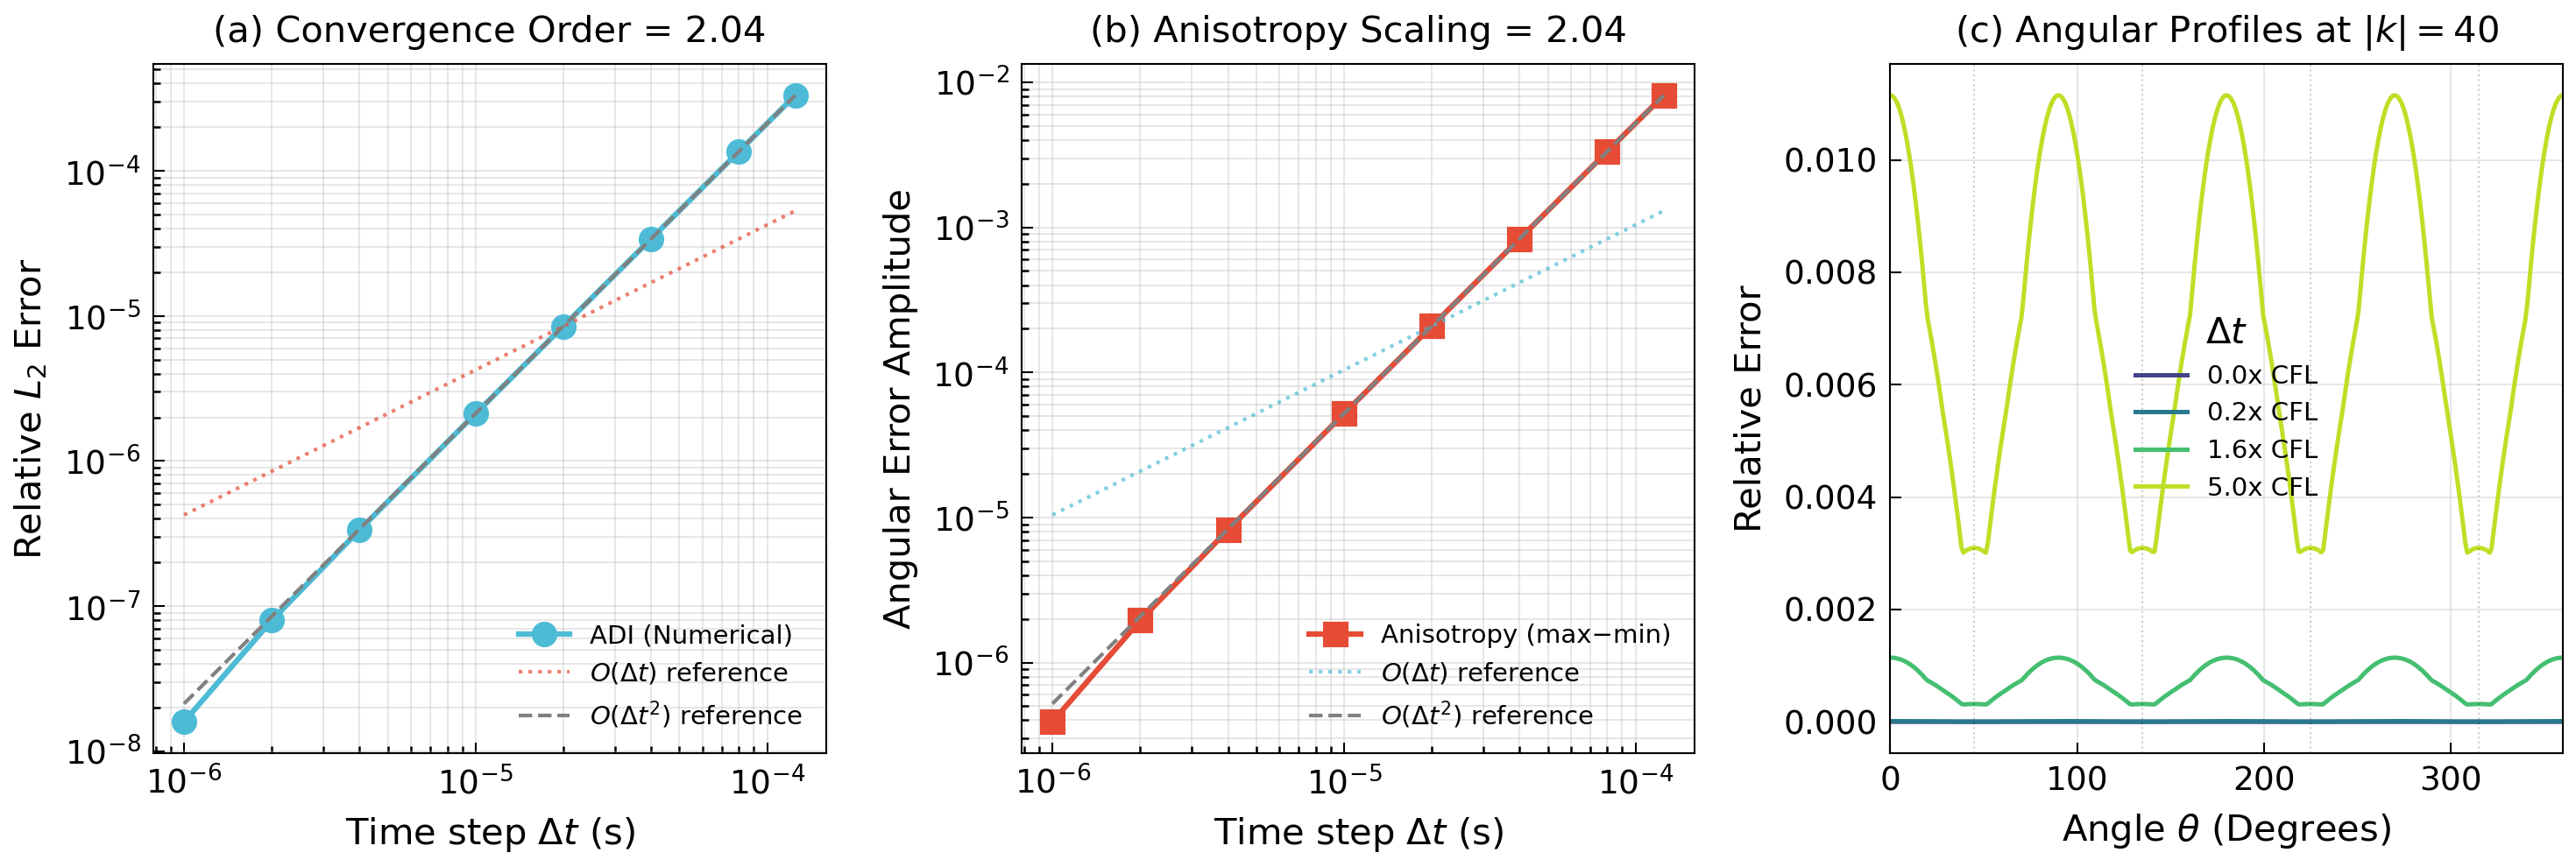

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import factorized
from scipy.fftpack import fftn, fftshift, fftfreq
from scipy.interpolate import RegularGridInterpolator

style_rcParams = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.figsize': (3.5, 3.5),
    'figure.dpi': 300,
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.0,
    'lines.markersize': 3,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'legend.frameon': False,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'savefig.format': 'png',
    'mathtext.fontset': 'dejavusans'
}
plt.rcParams.update(style_rcParams)


N = 100
L = 1.0
h = L / N
t_final = 0.0005

target_k_radius = 40 
alpha_complex = 1.0 + 0j 

x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)


np.random.seed(42)
U0 = np.random.normal(0, 1, (N, N)) + 0j


def solve_complex_system(U_in, dt, steps, alpha_complex, h, y_first=True):
    """
    ADI solver with selectable sweep order.
    y_first=True:  Y-implicit first, then X-implicit → error peaks at 90°, 270° (Y direction)
    y_first=False: X-implicit first, then Y-implicit → error peaks at 0°, 180° (X direction)
    
    Key insight: The direction solved FIRST accumulates more splitting error,
    causing error to peak in that direction in Fourier space.
    """
    u = np.copy(U_in).astype(np.complex128)
    N_grid = u.shape[0]
    k = alpha_complex * dt / (2 * h**2)
    
    diag_main = (1 + 2*k) * np.ones(N_grid); diag_main[0] = 1 + k; diag_main[-1] = 1 + k
    diag_upper = -k * np.ones(N_grid-1); diag_lower = -k * np.ones(N_grid-1)
    
    A_sparse = diags([diag_lower, diag_main, diag_upper], [-1, 0, 1], format='csc', dtype=np.complex128)
    solve_A = factorized(A_sparse)
    
    for _ in range(steps):
        if y_first:
            u_padded = np.pad(u, 1, mode='wrap')
            U_x_plus  = u_padded[1:-1, 2:]    
            U_x_minus = u_padded[1:-1, 0:-2]
            RHS1 = u + k * (U_x_minus - 2.0*u + U_x_plus)
            
            u_star = solve_A(RHS1)  
            
            u_star_padded = np.pad(u_star, 1, mode='wrap')
            U_y_plus  = u_star_padded[2:, 1:-1]   
            U_y_minus = u_star_padded[0:-2, 1:-1]
            RHS2 = u_star + k * (U_y_minus - 2.0*u_star + U_y_plus)
            
            u = solve_A(RHS2.T).T
            
        else:
            u_padded = np.pad(u, 1, mode='wrap')
            U_y_plus  = u_padded[2:, 1:-1]    
            U_y_minus = u_padded[0:-2, 1:-1]
            RHS1 = u + k * (U_y_minus - 2.0*u + U_y_plus)
            
            u_star = solve_A(RHS1.T).T
             
            u_star_padded = np.pad(u_star, 1, mode='wrap')
            U_x_plus  = u_star_padded[1:-1, 2:]   
            U_x_minus = u_star_padded[1:-1, 0:-2]
            RHS2 = u_star + k * (U_x_minus - 2.0*u_star + U_x_plus)
            
            u = solve_A(RHS2)

    return u


def get_exact_propagator(N, dt, alpha_complex):
    kx = fftfreq(N, d=L/N) * 2 * np.pi
    ky = fftfreq(N, d=L/N) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K2 = KX**2 + KY**2
    return np.exp(-alpha_complex * K2 * dt)

def scan_angular_error_zoomed():
    """Compare angular error profiles for X-first vs Y-first ADI sweep ordering."""
    print(f"Comparing ADI sweep orders at |k|={target_k_radius}...")
    
    dt = (h**2 / 4) * 100.0 
    steps = max(1, int(t_final / dt))
    
    fft_0 = fftn(U0)
    fft_exact = fft_0 * get_exact_propagator(N, steps * dt, alpha_complex)
    spec_exact = fftshift(np.abs(fft_exact))
    
    kx = fftshift(fftfreq(N, d=L/N)) * 2 * np.pi
    ky = fftshift(fftfreq(N, d=L/N)) * 2 * np.pi
    thetas = np.linspace(0, 2*np.pi, 360)
    circle_kx = target_k_radius * np.cos(thetas)
    circle_ky = target_k_radius * np.sin(thetas)
    points = np.column_stack((circle_kx, circle_ky))
    
    
    U_num_yfirst = solve_complex_system(U0, dt, steps, alpha_complex, h, y_first=True)
    fft_num_yfirst = fftn(U_num_yfirst)
    spec_num_yfirst = fftshift(np.abs(fft_num_yfirst))
    
    mask = spec_exact > 1e-15 
    error_map_yfirst = np.zeros_like(spec_num_yfirst)
    error_map_yfirst[mask] = np.abs(spec_num_yfirst[mask] / spec_exact[mask] - 1.0)
    
    interp_yfirst = RegularGridInterpolator((kx, ky), error_map_yfirst, bounds_error=False, fill_value=0)
    angular_error_yfirst = interp_yfirst(points)
    
    
    U_num_xfirst = solve_complex_system(U0, dt, steps, alpha_complex, h, y_first=False)
    fft_num_xfirst = fftn(U_num_xfirst)
    spec_num_xfirst = fftshift(np.abs(fft_num_xfirst))
    
    error_map_xfirst = np.zeros_like(spec_num_xfirst)
    error_map_xfirst[mask] = np.abs(spec_num_xfirst[mask] / spec_exact[mask] - 1.0)
    
    interp_xfirst = RegularGridInterpolator((kx, ky), error_map_xfirst, bounds_error=False, fill_value=0)
    angular_error_xfirst = interp_xfirst(points)
    
    print(f"Y-first (peaks 90°,270°): Min={np.min(angular_error_yfirst):.2e}, Max={np.max(angular_error_yfirst):.2e}")
    print(f"X-first (peaks 0°,180°):  Min={np.min(angular_error_xfirst):.2e}, Max={np.max(angular_error_xfirst):.2e}")

    
    fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
    
    
    ax = axes[0]
    ax.plot(np.degrees(thetas), angular_error_yfirst, color='#E64B35', linewidth=1.5)
    ax.set_xlim(0, 360)
    ax.set_xlabel(r'Angle $\theta$ (Degrees)')
    ax.set_ylabel('Relative Error')
    ax.set_title(r'(a) Y-implicit First $\rightarrow$ X-implicit')
    ax.grid(True, alpha=0.3)
    
    for angle in [90, 270]:
        ax.axvline(angle, color='#E64B35', linestyle='--', alpha=0.7, linewidth=1.5)
    for angle in [45, 135, 225, 315]:
        ax.axvline(angle, color='gray', linestyle=':', alpha=0.3)
    ax.annotate('Error peaks\nat 90°, 270°', xy=(90, ax.get_ylim()[1]*0.8 if ax.get_ylim()[1] > 0 else 100), 
                fontsize=8, color='#E64B35', ha='center')
    
    
    ax = axes[1]
    ax.plot(np.degrees(thetas), angular_error_xfirst, color='#4DBBD5', linewidth=1.5)
    ax.set_xlim(0, 360)
    ax.set_xlabel(r'Angle $\theta$ (Degrees)')
    ax.set_ylabel('Relative Error')
    ax.set_title(r'(b) X-implicit First $\rightarrow$ Y-implicit')
    ax.grid(True, alpha=0.3)
    
    for angle in [0, 180, 360]:
        ax.axvline(angle, color='#4DBBD5', linestyle='--', alpha=0.7, linewidth=1.5)
    for angle in [45, 135, 225, 315]:
        ax.axvline(angle, color='gray', linestyle=':', alpha=0.3)
    ax.annotate('Error peaks\nat 0°, 180°', xy=(270, ax.get_ylim()[1]*0.8 if ax.get_ylim()[1] > 0 else 200), 
                fontsize=8, color='#4DBBD5', ha='center')
    
    plt.tight_layout()
    plt.savefig('adi_sweep_order_comparison.png', dpi=300)
    print("Saved adi_sweep_order_comparison.png")
    
    plt.figure(figsize=(3.5, 3.5))
    plt.plot(np.degrees(thetas), angular_error_yfirst, color='#E64B35', linewidth=1.5)
    plt.xlim(0, 360)
    plt.xlabel(r'Angle $\theta$ (Degrees)')
    plt.ylabel('Relative Error')
    plt.title(f'Angular Profile (Y-first, $|k|={target_k_radius}$)')
    plt.grid(True, alpha=0.3)
    for angle in [90, 270]:
        plt.axvline(angle, color='b', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('angular_error_zoomed_y_first.png')
    print("Saved angular_error_zoomed_y_first.png")
    
    
    plt.figure(figsize=(3.5, 3.5))
    plt.plot(np.degrees(thetas), angular_error_xfirst, color='#4DBBD5', linewidth=1.5)
    plt.xlim(0, 360)
    plt.xlabel(r'Angle $\theta$ (Degrees)')
    plt.ylabel('Relative Error')
    plt.title(f'Angular Profile (X-first, $|k|={target_k_radius}$)')
    plt.grid(True, alpha=0.3)
    for angle in [0, 180]:
        plt.axvline(angle, color='b', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('angular_error_zoomed_x_first.png')
    print("Saved angular_error_zoomed_x_first.png")

def run_convergence_study():
    """
    Convergence study: verify O(dt²) for ADI method.
    Uses Richardson extrapolation: compare to fine-dt reference to isolate temporal error.
    Also shows angular anisotropy scaling.
    """
    print("="*60)
    print("CONVERGENCE STUDY: ADI Method (Richardson Extrapolation)")
    print("="*60)
    
    
    sigma0 = 0.05
    alpha_real = 1.0
    t_test = 0.002
    
    X_grid, Y_grid = np.meshgrid(np.linspace(0, L, N), np.linspace(0, L, N))
    
    def gaussian_exact(t):
        """Analytical solution for 2D Gaussian diffusion"""
        denom = sigma0**2 + 4 * alpha_real * t
        return (sigma0**2 / denom) * np.exp(-((X_grid - 0.5)**2 + (Y_grid - 0.5)**2) / denom)
    
    U0_gauss = gaussian_exact(0)
    
    
    dt_ref = t_test / 4000
    print(f"Computing reference solution with dt_ref = {dt_ref:.2e} (4000 steps)...")
    U_ref = np.real(solve_complex_system(U0_gauss + 0j, dt_ref, 4000, alpha_real + 0j, h))
    ref_norm = np.sqrt(np.mean(U_ref**2))
    fft_ref = fftn(U_ref)
    
    dt_base = h**2 / 4  
    
    
    step_counts = np.array([2000, 1000, 500, 200, 100, 50, 25, 16])
    dt_values = t_test / step_counts
    
    global_errors = []
    max_angular_errors = []
    anisotropy_amplitudes = []
    
    
    kx_grid = fftshift(fftfreq(N, d=L/N)) * 2 * np.pi
    ky_grid = fftshift(fftfreq(N, d=L/N)) * 2 * np.pi
    thetas = np.linspace(0, 2*np.pi, 360)
    circle_kx = target_k_radius * np.cos(thetas)
    circle_ky = target_k_radius * np.sin(thetas)
    points = np.column_stack((circle_kx, circle_ky))
    
    
    fft_exact_final = fft_ref
    
    print(f"\nGrid: N={N}, h={h:.4f}, CFL limit={dt_base:.2e}")
    print(f"Initial condition: Gaussian (σ₀={sigma0})")
    print(f"Target |k| for angular analysis: {target_k_radius}")
    print(f"Final time: t={t_test}")
    print("Comparing to fine-dt reference (isolates temporal error)")
    print("-"*60)
    
    for i, (dt, steps) in enumerate(zip(dt_values, step_counts)):
        
        U_num = np.real(solve_complex_system(U0_gauss + 0j, dt, steps, alpha_real + 0j, h))
        fft_num = fftn(U_num)
        
        
        l2_error = np.sqrt(np.mean((U_num - U_ref)**2))
        global_l2 = l2_error / ref_norm
        global_errors.append(global_l2)
        
        
        spec_num = fftshift(np.abs(fft_num))
        spec_ref = fftshift(np.abs(fft_ref))
        
        mask = spec_ref > 1e-12
        error_map = np.zeros_like(spec_num, dtype=float)
        error_map[mask] = np.abs(spec_num[mask] / spec_ref[mask] - 1.0)
        
        interp = RegularGridInterpolator((kx_grid, ky_grid), error_map, 
                                         bounds_error=False, fill_value=0)
        angular_error = interp(points)
        
        max_angular_errors.append(np.max(angular_error))
        anisotropy_amplitudes.append(np.max(angular_error) - np.min(angular_error))
        
        print(f"dt = {dt:.2e} ({dt/dt_base:5.1f}x CFL) | "
              f"steps={steps:4d} | L2={global_l2:.2e} | "
              f"max_angular={np.max(angular_error):.2e} | "
              f"anisotropy={anisotropy_amplitudes[-1]:.2e}")
    
    
    dt_values = np.array(dt_values)
    global_errors = np.array(global_errors)
    max_angular_errors = np.array(max_angular_errors)
    anisotropy_amplitudes = np.array(anisotropy_amplitudes)
    
    
    valid = ~np.isnan(global_errors) & (global_errors > 0)
    if np.sum(valid) >= 3:
        coeffs = np.polyfit(np.log(dt_values[valid]), np.log(global_errors[valid]), 1)
        order_global = coeffs[0]
        
        coeffs_aniso = np.polyfit(np.log(dt_values[valid]), 
                                   np.log(anisotropy_amplitudes[valid] + 1e-16), 1)
        order_aniso = coeffs_aniso[0]
    else:
        order_global = np.nan
        order_aniso = np.nan
    
    print("-"*60)
    print(f"Fitted convergence order (global L2): {order_global:.2f}")
    print(f"Fitted convergence order (anisotropy): {order_aniso:.2f}")
    print("Expected for Crank-Nicolson ADI: O(dt²) → order ≈ 2.0")
    print("="*60)
    
    
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
    
    
    ax = axes[0]
    ax.loglog(dt_values, global_errors, 'o-', color='#4DBBD5', 
              linewidth=1.5, markersize=6, label='ADI (Numerical)')
    
    
    dt_plot = dt_values[valid]
    mid_idx = len(dt_plot)//2
    
    
    scale1 = global_errors[valid][mid_idx] / dt_plot[mid_idx]
    ax.loglog(dt_plot, scale1 * dt_plot, ':', color='#E64B35', 
              linewidth=1, alpha=0.7, label=r'$O(\Delta t)$ reference')
    
    
    scale2 = global_errors[valid][mid_idx] / dt_plot[mid_idx]**2
    ax.loglog(dt_plot, scale2 * dt_plot**2, '--', color='gray', 
              linewidth=1, label=r'$O(\Delta t^2)$ reference')
    
    ax.set_xlabel(r'Time step $\Delta t$ (s)')
    ax.set_ylabel(r'Relative $L_2$ Error')
    ax.set_title(f'(a) Convergence Order = {order_global:.2f}')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3, which='both')
    
    
    ax = axes[1]
    ax.loglog(dt_values, anisotropy_amplitudes, 's-', color='#E64B35', 
              linewidth=1.5, markersize=6, label='Anisotropy (max−min)')
    
    
    if not np.isnan(order_aniso):
        mid_idx_a = len(dt_plot)//2
        
        scale1_a = anisotropy_amplitudes[valid][mid_idx_a] / dt_plot[mid_idx_a]
        ax.loglog(dt_plot, scale1_a * dt_plot, ':', color='#4DBBD5', 
                  linewidth=1, alpha=0.7, label=r'$O(\Delta t)$ reference')
        
        scale2_a = anisotropy_amplitudes[valid][mid_idx_a] / dt_plot[mid_idx_a]**2
        ax.loglog(dt_plot, scale2_a * dt_plot**2, '--', color='gray', 
                  linewidth=1, label=r'$O(\Delta t^2)$ reference')
    
    ax.set_xlabel(r'Time step $\Delta t$ (s)')
    ax.set_ylabel(r'Angular Error Amplitude')
    ax.set_title(f'(b) Anisotropy Scaling = {order_aniso:.2f}')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3, which='both')
    
    
    ax = axes[2]
    n_dt = len(dt_values)
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, n_dt))
    
    
    spec_ref_plot = fftshift(np.abs(fft_ref))
    
    
    selected_indices = [0, n_dt//3, 2*n_dt//3, n_dt-1]
    for idx in selected_indices:
        dt = dt_values[idx]
        steps = step_counts[idx]
        
        U_num = solve_complex_system(U0_gauss + 0j, dt, steps, alpha_real + 0j, h)
        fft_num = fftn(np.real(U_num))
        
        spec_num = fftshift(np.abs(fft_num))
        
        mask = spec_ref_plot > 1e-12
        error_map = np.zeros_like(spec_num, dtype=float)
        error_map[mask] = np.abs(spec_num[mask] / spec_ref_plot[mask] - 1.0)
        
        interp = RegularGridInterpolator((kx_grid, ky_grid), error_map, 
                                         bounds_error=False, fill_value=0)
        angular_error = interp(points)
        
        ax.plot(np.degrees(thetas), angular_error, color=colors[idx], 
                linewidth=1.2, label=f'{dt/dt_base:.1f}x CFL')
    
    ax.set_xlabel(r'Angle $\theta$ (Degrees)')
    ax.set_ylabel('Relative Error')
    ax.set_title(f'(c) Angular Profiles at $|k|={target_k_radius}$')
    ax.set_xlim(0, 360)
    ax.legend(fontsize=7, title=r'$\Delta t$')
    ax.grid(True, alpha=0.3)
    
    
    for angle in [45, 135, 225, 315]:
        ax.axvline(angle, color='k', linestyle=':', alpha=0.2, linewidth=0.5)
    
    plt.tight_layout()
        
    return dt_values, global_errors, order_global


if __name__ == '__main__':
    
    scan_angular_error_zoomed()
    run_convergence_study()

COMPREHENSIVE STABILITY ANALYSIS
Grid size: 50x50
Grid spacing: dx = dy = 0.0200
Thermal diffusivities (α): [0.5, 1.0, 2.0]
steps: [9999 9102 8286 7543 6866 6250 5689 5179 4714 4291 3906 3556 3237 2947
 2682 2442 2222 2023 1842 1676 1526 1389 1264 1151 1048  954  868  790
  719  655  596  542  494  449  409  372  339  308  281  255  232  212
  193  175  159  145  132  120  109  100]

Testing Explicit (Forward Euler)...
Saved comparison_explicit_adi_initial_stability.png


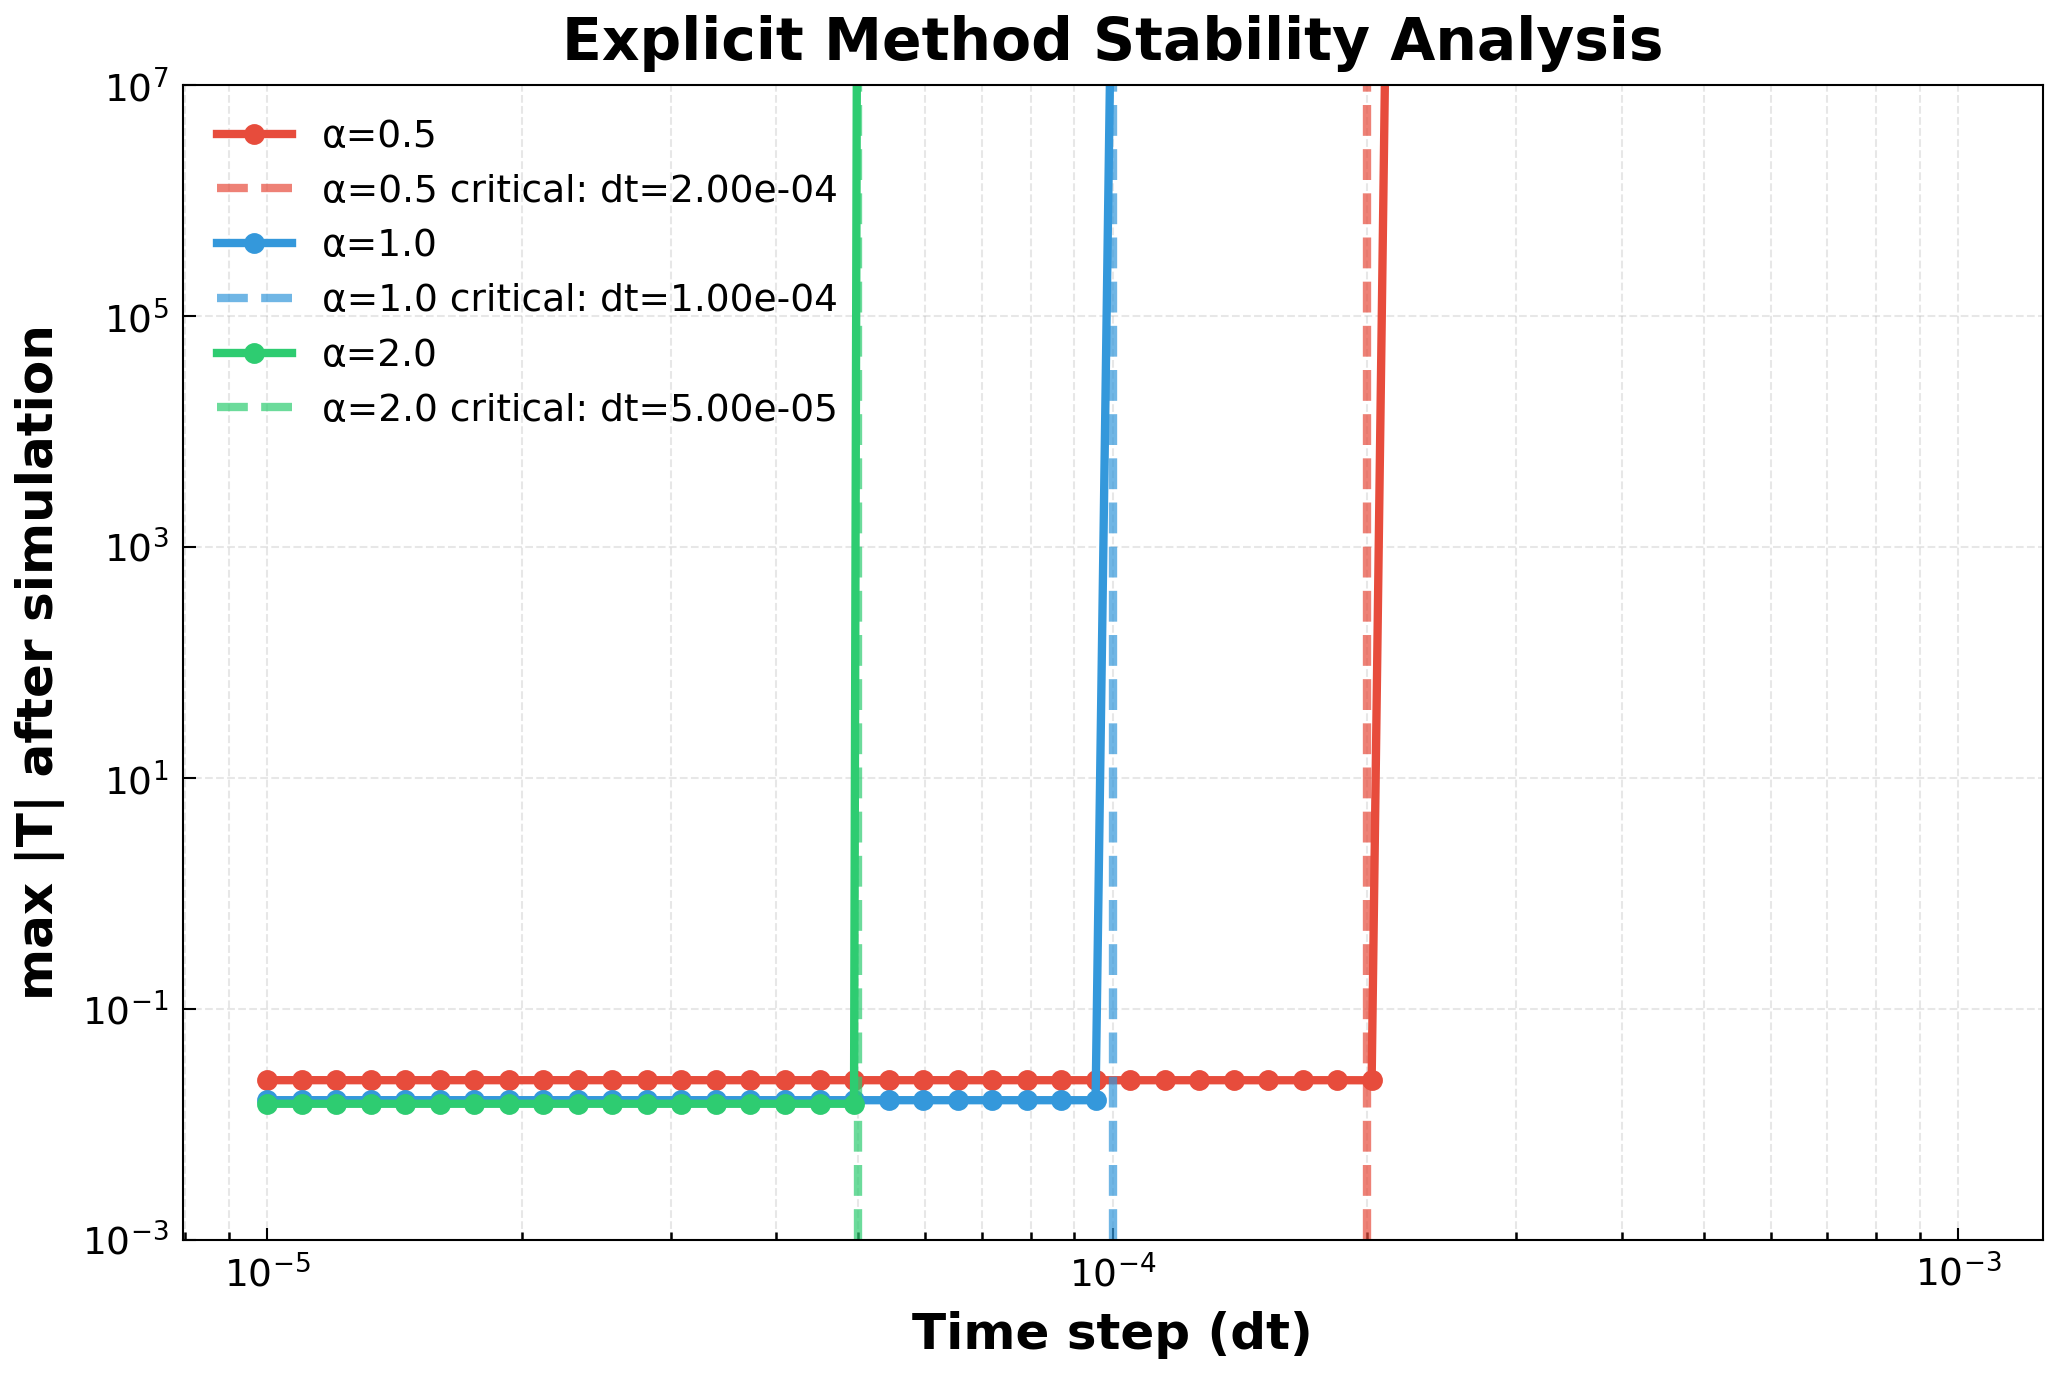

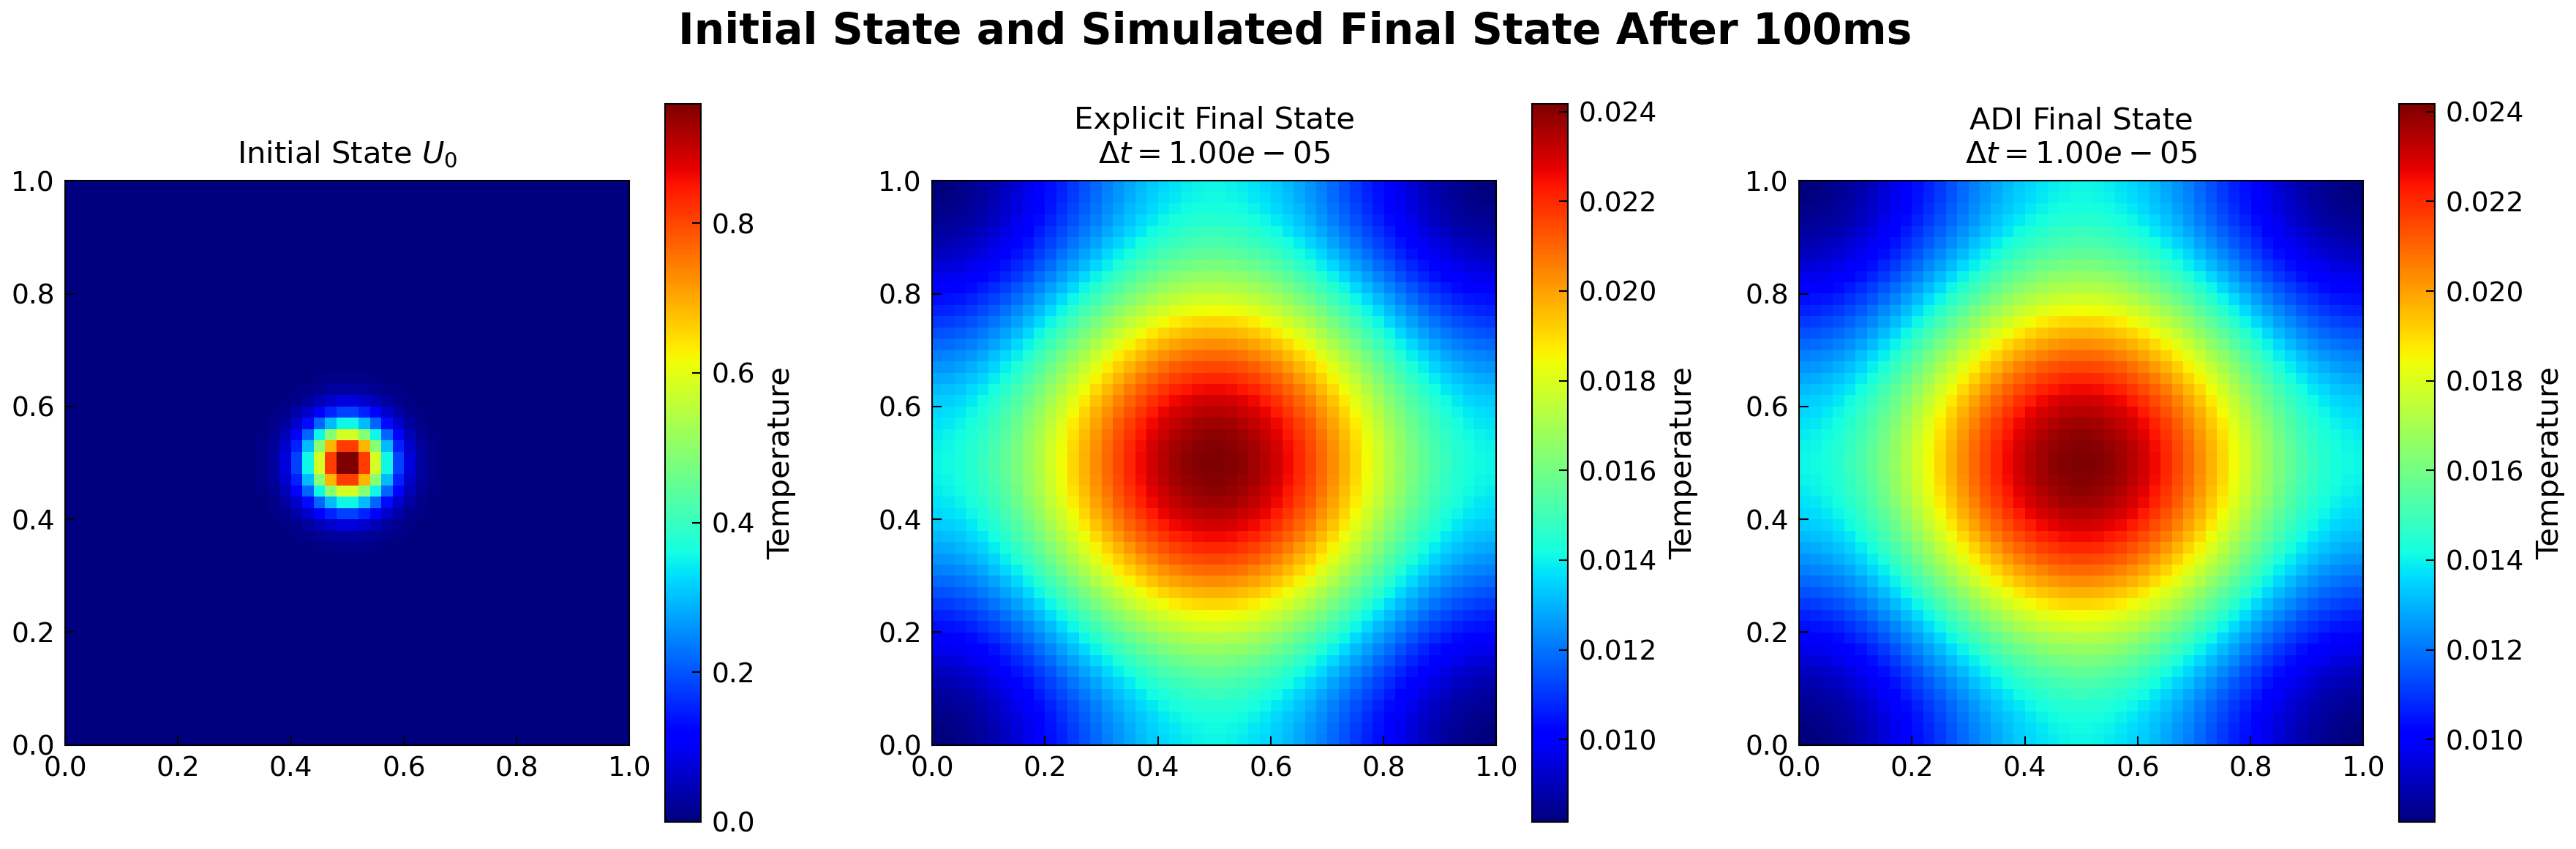

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

"""
Comprehensive Stability Analysis for all Heat Diffusion Methods in the Project
===============================================================================

This script analyzes the stability of:
1. Explicit (Forward Euler) method
2. Crank-Nicolson (ADI) implicit method

For each method, we test with various time steps and compare against theoretical
stability criteria.
"""

N = 50
dx = 1.0 / N
dy = dx  

x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
xx, yy = np.meshgrid(x, y)
T0 = np.exp(-200 * ((xx - 0.5)**2 + (yy - 0.5)**2)).astype(float)

alphas = [0.5, 1.0, 2.0] 

time = 0.1


# ============EXPLICIT===============================

def laplacian(T, dx):
    """Compute 2D Laplacian using finite differences with periodic BC."""
    return (
        np.roll(T, 1, axis=0) +
        np.roll(T, -1, axis=0) +
        np.roll(T, 1, axis=1) +
        np.roll(T, -1, axis=1) -
        4*T
    ) / dx**2


def explicit_heat_step(T, alpha, dx, dt, steps):
    """
    Explicit (Forward Euler) method for heat equation.
    Stability condition: dt < dx²/(4*alpha) for 2D
    """
    T = T.copy().astype(float)
    maxvals = [np.max(np.abs(T))]
    
    for _ in range(steps):
        T = T + alpha * dt * laplacian(T, dx)
        
        if not np.isfinite(T).all():
            maxvals.append(np.inf)
            return T, maxvals, False 
        
        maxvals.append(np.max(np.abs(T)))

    if maxvals[-1] > 10 * maxvals[0]:
        return T, maxvals, False
    
    return T, maxvals, True


# =================CN ADI==================================
def tri_disc(N, a):
    """
    Creates the 1D implicit operator matrix (I - a*D_xx)
    with Neumann boundary conditions.
    """
    M = (np.diag(-a * np.ones(N-1), k=-1) +
         np.diag((1+2*a) * np.ones(N), k=0) +
         np.diag(-a * np.ones(N-1), k=1))
    
    M[0, 0] = 1+a
    M[0, 1] = -a
    M[-1, -1] = 1+a
    M[-1, -2] = -a
    
    return M


def crank_nicolson_step(T0, alpha, dx, dt, steps):
    """
    Crank-Nicolson (ADI) method for heat equation.
    Uses Alternating Direction Implicit (ADI) splitting with direct linear solvers.
    """
    N = T0.shape[0]
    h = dx
    k = alpha * dt / (2 * h**2)
    
    A = tri_disc(N, k)
    C = tri_disc(N, k)
    
    u = T0.copy().astype(float)
    maxvals = [np.max(np.abs(u))]
    
    for it in range(steps):
       
        u_padded = np.pad(u, 1, mode='edge')
        U_y_plus  = u_padded[1:-1, 2:]   
        U_y_minus = u_padded[1:-1, 0:-2] 
        
        RHS1 = u + k * (U_y_minus - 2.0*u + U_y_plus)

        try:
            u_star = np.linalg.solve(A, RHS1)
        except np.linalg.LinAlgError:
            maxvals.append(np.inf)
            return u, maxvals, False

        u_padded = np.pad(u_star, 1, mode='edge')
        U_x_plus  = u_padded[2:, 1:-1]   # u[i+1, j]
        U_x_minus = u_padded[0:-2, 1:-1] # u[i-1, j]
        
        RHS2 = u_star + k * (U_x_minus - 2.0*u_star + U_x_plus)

        try:
            u = np.linalg.solve(C, RHS2.T).T
        except np.linalg.LinAlgError:
            maxvals.append(np.inf)
            return u, maxvals, False
        
        if not np.isfinite(u).all():
            maxvals.append(np.inf)
            return u, maxvals, False
        
        maxvals.append(np.max(np.abs(u)))
    
    return u, maxvals, True


def test_stability(method_func, method_name, T0, dx, alphas, dts, steps=100):
    """Test stability for a given method across different parameters."""
    print(f"\nTesting {method_name}...")
    results = {}
    stability_map = {}
    
    for alpha in alphas:
        max_last = []
        is_stable = []
        i_stability = 0
        for dt in dts:
            _, maxvals, stable = method_func(T0, alpha, dx, dt, steps[i_stability])
            max_last.append(maxvals[-1] if np.isfinite(maxvals[-1]) else 1e10)
            is_stable.append(stable)
            i_stability += 1
        
        results[alpha] = np.array(max_last, dtype=float)
        stability_map[alpha] = is_stable
    
    return results, stability_map


print("="*80)
print("COMPREHENSIVE STABILITY ANALYSIS")
print("="*80)
print(f"Grid size: {N}x{N}")
print(f"Grid spacing: dx = dy = {dx:.4f}")
print(f"Thermal diffusivities (α): {alphas}")

dts = np.logspace(-5, -3, 50)
steps = (time // dts)
steps = steps.astype(int)
print(f'steps: {steps}')

explicit_results, explicit_stability = test_stability(
    explicit_heat_step, "Explicit (Forward Euler)", T0, dx, alphas, dts, steps
)

fig, ax1 = plt.subplots(figsize=(8, 5))

colors = ['#e74c3c', '#3498db', '#2ecc71']  # Red, Blue, Green

for i, alpha in enumerate(alphas):
    yvals = explicit_results[alpha]
    yvals = np.where(np.isfinite(yvals), yvals, 1e10)
    
    ax1.plot(dts, yvals, marker='o', markersize=4, 
             label=f"α={alpha}", color=colors[i], linewidth=2)
    
    dt_crit = dx**2 / (4 * alpha)
    ax1.axvline(dt_crit, ls='--', alpha=0.7, color=colors[i], linewidth=2,
                label=f"α={alpha} critical: dt={dt_crit:.2e}")

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylim(bottom = None, top = 1e10)
ax1.set_xlabel("Time step (dt)", fontsize=12, fontweight='bold')
ax1.set_ylabel("max |T| after simulation", fontsize=12, fontweight='bold')
ax1.set_title("Explicit Method Stability Analysis", fontsize=14, fontweight='bold')
ax1.grid(True, which='both', ls='--', alpha=0.3)
ax1.legend(fontsize=9, loc='upper left')
ax1.set_ylim([1e-3, 1e7])

T_explicit,_,_ = explicit_heat_step(T0, alphas[0], dx, dts[0], steps[0])
T_implicit,_,_ = crank_nicolson_step(T0, alphas[0], dx, dts[0], steps[0])

plt.savefig('explicit_stability_analysis.png',
            dpi=300, bbox_inches='tight')

plt.figure(figsize=(12, 4))

style_rcParams = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.figsize': (3.5, 3.5),
    'figure.dpi': 300,
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.0,
    'lines.markersize': 3,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'legend.frameon': False,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'savefig.format': 'png',
    'mathtext.fontset': 'dejavusans'
}
plt.rcParams.update(style_rcParams)

# 1. Initial condition
plt.subplot(1, 3, 1)
plt.imshow(T0, cmap='jet', extent=[0,1,0,1], origin='lower')
plt.title("Initial State $U_0$")
plt.colorbar(label='Temperature')

# 2. Explicit solution
plt.subplot(1, 3, 2)
plt.imshow(T_explicit, cmap='jet', extent=[0,1,0,1], origin='lower')
plt.title(f"Explicit Final State\n$\\Delta t = {dts[0]:.2e}$")
plt.colorbar(label='Temperature')

# 3. ADI solution
plt.subplot(1, 3, 3)
plt.imshow(T_implicit, cmap='jet', extent=[0,1,0,1], origin='lower')
plt.title(f"ADI Final State\n$\\Delta t = {dts[0]:.2e}$")
plt.colorbar(label='Temperature')

plt.suptitle("Initial State and Simulated Final State After 100ms", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("comparison_explicit_adi_initial_stability.png")
print("Saved comparison_explicit_adi_initial_stability.png")

plt.show()

In [27]:
%pip install imageio

Starting Calibrated Simulation...
Target Normal Temp: ~600.0 K
Target Meltdown Temp: >3100.0 K
Meltdown threshold reached at t=40.04s. Saving snapshot...
Snapshot saved: meltdown_event.png
Time: 57.3s | Max Temp: 6979 K | Status: CLADDING FAILURE
Rendering high-contrast visualization...
Saved: reactor_accurate.gif


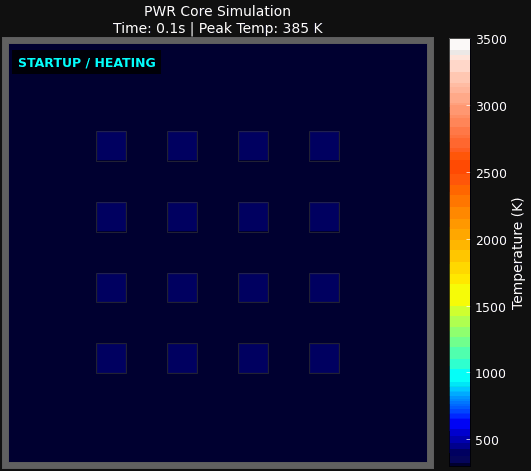

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
from io import BytesIO
from PIL import Image as PILImage
from IPython.display import Image
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle


Nx, Ny = 120, 120 
Lx, Ly = 1.0, 1.0
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y)


core_mask = np.zeros_like(X, dtype=bool)
rod_centers = np.linspace(0.25, 0.75, 4)
rod_size = 0.07 
for rx in rod_centers:
    for ry in rod_centers:
        rod_mask = (X >= rx - rod_size/2) & (X <= rx + rod_size/2) & \
                   (Y >= ry - rod_size/2) & (Y <= ry + rod_size/2)
        core_mask = core_mask | rod_mask


alpha = np.ones_like(X)
alpha_water = 2.0e-5   # Water alpha diffusivity
alpha_fuel  = 1.0e-4   # Fuel alpha  diffusivity
alpha[:, :] = alpha_water
alpha[core_mask] = alpha_fuel


u = np.ones_like(X) * 300.0      

core_heating_strength = 800.0 
cooling_failure_time = 40.0  

operating_temp = 600.0
zirconium_melt = 2100.0  
uranium_melt   = 3100.0  

dt = 0.15 * min(dx, dy)**2 / np.max(alpha)

simulation_time = 100.0      
total_steps = int(simulation_time / dt)
steps_per_frame = 60         

frames = []
times = []
max_temps = []
status_log = []

colors = [(0.0,  "#000030"), (0.1,  "#0000FF"), (0.2,  "#00FFFF"), (0.4,  "#FFFF00"), (0.7,  "#FF4500"), (1.0,  "#FFFFFF")]
reactor_cmap = LinearSegmentedColormap.from_list("reactor_thermal", colors)

def laplacian(U):
    U_padded = np.pad(U, 1, mode='edge')
    d2x = (U_padded[1:-1, 2:] - 2*U_padded[1:-1, 1:-1] + U_padded[1:-1, :-2]) / dx**2
    d2y = (U_padded[2:, 1:-1] - 2*U_padded[1:-1, 1:-1] + U_padded[:-2, 1:-1]) / dy**2
    return d2x + d2y

print(f"Starting Calibrated Simulation...")
print(f"Target Normal Temp: ~{operating_temp} K")
print(f"Target Meltdown Temp: >{uranium_melt} K")

t = 0.0
current_status = "STARTUP"

meltdown_captured = False

for step in range(total_steps):

    if t < cooling_failure_time:

        u[0,:] = u[-1,:] = u[:,0] = u[:,-1] = 300.0
        

        if np.max(u) > 550:
            current_status = "NORMAL OPERATION (600 K)"
        else:
            current_status = "STARTUP / HEATING"
            
    else:

        if np.max(u) > uranium_melt:
            current_status = "!!! CORE MELTDOWN !!!"

            
        if not meltdown_captured:
            print(f"Meltdown threshold reached at t={t:.2f}s. Saving snapshot...")
            
            
            fig_snap, ax_snap = plt.subplots(figsize=(6, 6), dpi=150)
            
           
            bg_color = "#101010" 
            fig_snap.patch.set_facecolor(bg_color)
            ax_snap.set_facecolor(bg_color)
            
            im_snap = ax_snap.imshow(u, cmap=reactor_cmap, origin="lower",
                                     extent=[0, 1, 0, 1], vmin=300, vmax=3500)
            
            
            for rx in rod_centers:
                for ry in rod_centers:
                    rect = Rectangle((rx - rod_size/2, ry - rod_size/2), rod_size, rod_size,
                                     linewidth=1, edgecolor='white', facecolor='none', alpha=0.5)
                    ax_snap.add_patch(rect)

           
            for spine in ax_snap.spines.values():
                spine.set_edgecolor('#606060')
                spine.set_linewidth(5)

            
            ax_snap.text(0.03, 0.94, "!!! CORE MELTDOWN !!!", color="red", weight="bold", size=10,
                    transform=ax_snap.transAxes, bbox=dict(facecolor='black', alpha=0.8, edgecolor='none'))
            
            ax_snap.set_title(f"CRITICAL FAILURE EVENT\nTime: {t:.2f}s | Temp: {np.max(u):.0f} K", color='white')
            ax_snap.set_xticks([])
            ax_snap.set_yticks([])
            
            # Save the file
            fig_snap.savefig("meltdown_event.png", bbox_inches='tight', facecolor=bg_color)
            plt.close(fig_snap)
            
            print("Snapshot saved: meltdown_event.png")
            meltdown_captured = True 

            
        elif np.max(u) > zirconium_melt:
            current_status = "CLADDING FAILURE"
        else:
            current_status = "LOSS OF COOLANT (LOCA)"


    lap = laplacian(u)
    u_new = u + alpha * dt * lap
    u_new[core_mask] += core_heating_strength * dt
    u = u_new
    t += dt

 
    if step % steps_per_frame == 0:
        frames.append(u.copy())
        times.append(t)
        max_temps.append(np.max(u))
        status_log.append(current_status)
        
        if len(frames) % 10 == 0:
            print(f"Time: {t:.1f}s | Max Temp: {np.max(u):.0f} K | Status: {current_status}")

print("Rendering high-contrast visualization...")

gif_frames = []
for i, frame in enumerate(frames):
    fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
    
   
    bg_color = "#101010" 
    fig.patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)

    # fun title color
    if "MELTDOWN" in status_log[i]:
        text_color = "#FF0000"
    elif "CLADDING" in status_log[i]:
        text_color = "#FFA500" 
    else:
        text_color = "#00FFFF" 

    im = ax.imshow(
        frame, cmap=reactor_cmap, origin="lower",
        extent=[0, 1, 0, 1], vmin=300, vmax=3500 
    )
    
    for rx in rod_centers:
        for ry in rod_centers:
            # Color of outline changes if rod is melting
            edge_c = 'white' if max_temps[i] > zirconium_melt else '#404040'
            rect = Rectangle((rx - rod_size/2, ry - rod_size/2), rod_size, rod_size,
                             linewidth=1, edgecolor=edge_c, facecolor='none', alpha=0.5)
            ax.add_patch(rect)

    # Overlay Tank Walls
    for spine in ax.spines.values():
        spine.set_edgecolor('#606060')
        spine.set_linewidth(5)


    ax.text(0.03, 0.94, status_log[i], color=text_color, weight="bold", size=9,
            transform=ax.transAxes, bbox=dict(facecolor='black', alpha=0.8, edgecolor='none'))

  
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Temperature (K)", color='white')
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

    ax.set_title(f"PWR Core Simulation\nTime: {times[i]:.1f}s | Peak Temp: {max_temps[i]:.0f} K", color='white')
    ax.set_xticks([])
    ax.set_yticks([])

    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', facecolor=bg_color)
    buf.seek(0)
    img = np.array(PILImage.open(buf))
    gif_frames.append(img)
    plt.close(fig)
    buf.close()


last_frame = gif_frames[-1]
for _ in range(30):
    gif_frames.append(last_frame)

imageio.mimsave("reactor_accurate.gif", gif_frames, fps=4)
print("Saved: reactor_accurate.gif")
Image(filename="reactor_accurate.gif")

<unknown>:178: SyntaxWarning: invalid escape sequence '\D'
<unknown>:179: SyntaxWarning: invalid escape sequence '\D'
<>:178: SyntaxWarning: invalid escape sequence '\D'
<>:179: SyntaxWarning: invalid escape sequence '\D'
<>:178: SyntaxWarning: invalid escape sequence '\D'
<>:179: SyntaxWarning: invalid escape sequence '\D'
<ipython-input-29-5246288d4430>:178: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Time Step ($\Delta t$) vs. $L_2$ Error (Accuracy)')
<ipython-input-29-5246288d4430>:179: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Time Step $\Delta t$ (s)')


For alpha=0.7, the most accurate timestep is 2.38e-05
Testing dt = 1.00e-07...
steps: 50000
Testing dt = 4.06e-06...
steps: 1232
Testing dt = 8.01e-06...
steps: 623
Testing dt = 1.20e-05...
steps: 417
Testing dt = 1.59e-05...
steps: 313
Testing dt = 1.99e-05...
steps: 251
Testing dt = 2.38e-05...
steps: 209
Testing dt = 2.78e-05...
steps: 179
Testing dt = 3.18e-05...
steps: 157
Testing dt = 3.57e-05...
steps: 140

Plot saved as error_vs_timestep_linear_scaled.png

Explicit Stability Limit (dt_CFL) for N=100 grid: 3.57e-05
dt range used: 1.00e-07 to 3.57e-05


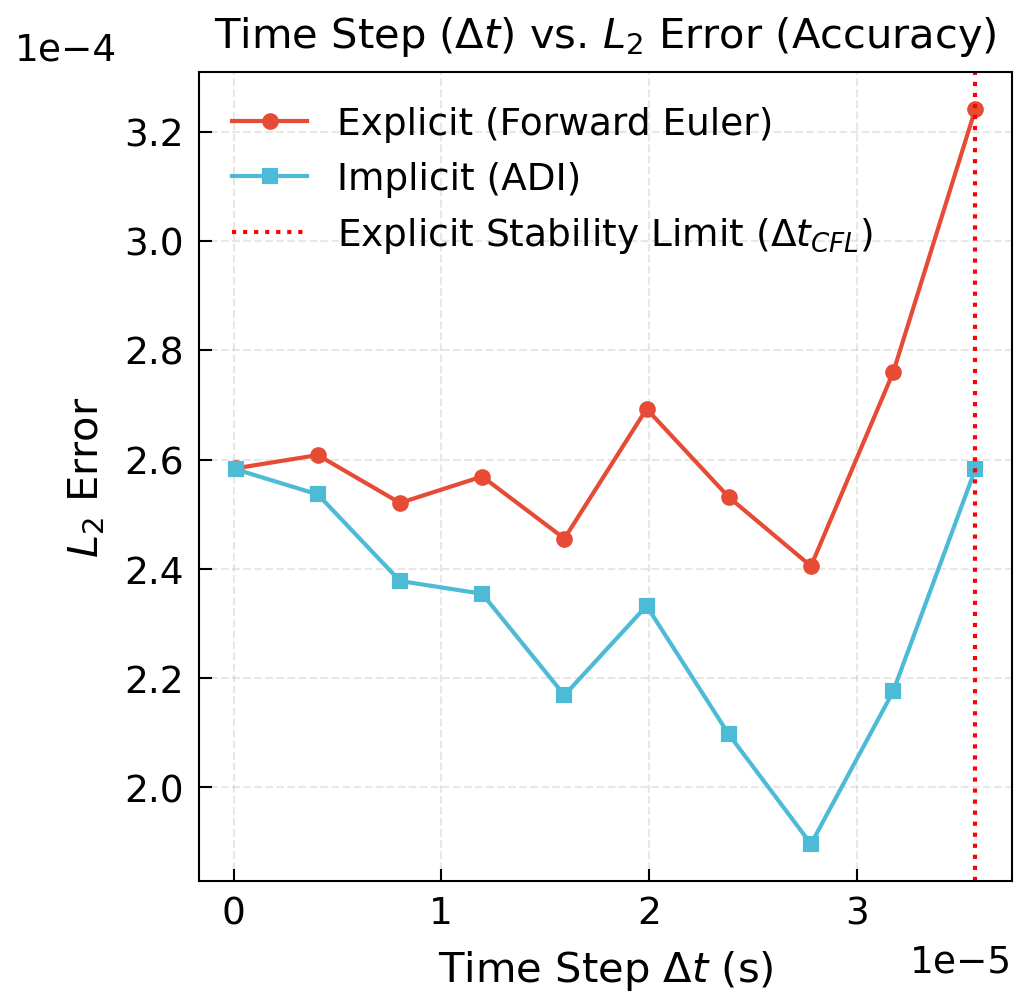

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

nature_rcParams = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.figsize': (3.5, 3.5),
    'figure.dpi': 300,
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.0,
    'lines.markersize': 3,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'legend.frameon': False,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'savefig.format': 'png',
    'mathtext.fontset': 'dejavusans'
}
plt.rcParams.update(nature_rcParams)

alpha = 0.7
N = 100 
L = 1.0     
h = L / N   

sigma0 = 0.05 # Initial width of the Gaussian
x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)

def analytical_solution(X, Y, t, alpha, sigma0):
    numerator = sigma0**2
    denominator = sigma0**2 + 4 * alpha * t
    exponent = -((X - 0.5)**2 + (Y - 0.5)**2) / denominator
    U_exact = (numerator / denominator) * np.exp(exponent)
    return U_exact

U0 = analytical_solution(X, Y, t=0, alpha=alpha, sigma0=sigma0)

def tri_disc(N, a):
    M = (np.diag(-a * np.ones(N-1), k=-1) +
         np.diag((1 + 2*a) * np.ones(N), k=0) +
         np.diag(-a * np.ones(N-1), k=1))
    
    M[0, 0] = 1 + a
    M[0, 1] = -a
    M[-1, -1] = 1 + a
    M[-1, -2] = -a
    
    return M

def solve_explicit(U_initial, dt, t_final, alpha, h):

    u = np.copy(U_initial)
    t = 0.0
    
    C = alpha * dt / h**2 
    if C > 0.25:
        print(f"Warning: Explicit method unstable for dt={dt:.2e}. C={C:.2f}")

    max_steps = int(t_final / dt)
    print(f"steps: {max_steps}")
    for _ in range(max_steps):
  
        laplacian = (u[2:, 1:-1] + u[:-2, 1:-1] + u[1:-1, 2:] + u[1:-1, :-2] - 4 * u[1:-1, 1:-1]) / h**2
        
        u[1:-1, 1:-1] = u[1:-1, 1:-1] + dt * alpha * laplacian
        
        u[0, :] = u[1, :]
        u[-1, :] = u[-2, :]
        u[:, 0] = u[:, 1]
        u[:, -1] = u[:, -2]
        
        t += dt
    
    return u

def solve_implicit_adi(U_initial, dt, t_final, alpha, h):
    u = np.copy(U_initial)
    t = 0.0
    
    k = alpha * dt / (2 * h**2)
    
    A = tri_disc(N, k)
    
    max_steps = int(t_final / dt)
    
    for _ in range(max_steps):
        
        u_padded = np.pad(u, 1, mode='edge')
        U_y_plus = u_padded[1:-1, 2:]     
        U_y_minus = u_padded[1:-1, 0:-2]   
        RHS1 = u + k * (U_y_minus - 2.0*u + U_y_plus)
        
        u_star = solve(A, RHS1) 

        u_star_padded = np.pad(u_star, 1, mode='edge')
        U_x_plus = u_star_padded[2:, 1:-1]   
        U_x_minus = u_star_padded[0:-2, 1:-1] 
        RHS2 = u_star + k * (U_x_minus - 2.0*u_star + U_x_plus)
        
        u = solve(A, RHS2.T).T
        
        t += dt
        
    return u

dt_sweet_spot = (h**2) / (6 * alpha)

print(f"For alpha={alpha}, the most accurate timestep is {dt_sweet_spot:.2e}")

def calculate_error(U_numerical, U_exact):
    """
    Calculates the L2 norm of the error (Root Mean Square Error).
    """
    return np.sqrt(np.mean((U_numerical - U_exact)**2))

def run_simulation_and_plot_error():
    t_final = 0.005
    
    # Calculate stability limit
    dt_cfl = 0.25 * h**2 / alpha
    
    # Set dt range to go up to the critical dt
    #dt_range = np.logspace(-7, np.log10(dt_cfl), 20)
    dt_range = np.linspace(1e-7, dt_cfl, 10)

    U_exact_final = analytical_solution(X, Y, t_final, alpha, sigma0)
    
    error_explicit = []
    error_adi = []
    
    for dt in dt_range:
        print(f"Testing dt = {dt:.2e}...")
        
        try:
            U_explicit = solve_explicit(U0, dt, t_final, alpha, h)
            err_exp = calculate_error(U_explicit, U_exact_final)
            error_explicit.append(err_exp)
        except Exception as e:
            print(f"Explicit unstable at dt = {dt:.2e}")
            error_explicit.append(np.nan)

        U_adi = solve_implicit_adi(U0, dt, t_final, alpha, h)
        err_adi = calculate_error(U_adi, U_exact_final)
        error_adi.append(err_adi)
    
    plt.figure()
    
    plt.plot(dt_range, error_explicit, 'o-', label='Explicit (Forward Euler)', 
               color='#E64B35')
    plt.plot(dt_range, error_adi, 's-', label='Implicit (ADI)', 
               color='#4DBBD5')

    # Show stability limit as reference
    plt.axvline(dt_cfl, color='red', linestyle=':',
                label=r'Explicit Stability Limit ($\Delta t_{CFL}$)')
    
    # Zoom in more on the x-axis
    #plt.xlim(0, 3.5e-5)
    
    # Calculate appropriate y-axis limits to show the difference - zoom in more
    #plt.ylim(2.0e-4, 3.2e-4)
    
    plt.title('Time Step ($\Delta t$) vs. $L_2$ Error (Accuracy)')
    plt.xlabel('Time Step $\Delta t$ (s)')
    plt.ylabel(r'$L_2$ Error')
    plt.legend()
    

    ax = plt.gca()
    ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
    ax.yaxis.get_offset_text().set_position((-0.1, 0))
    ax.yaxis.get_offset_text().set_horizontalalignment('right')
    
    #ax.set_xticks(np.linspace(0, 3.5e-5, 6))
    #ax.set_yticks(np.linspace(2.0e-4, 3.2e-4, 6))
    ax.grid(alpha= 0.3, ls = "--")
    plt.savefig('error_vs_timestep_linear_scaled.png')
    print("\nPlot saved as error_vs_timestep_linear_scaled.png")
    
    print(f"\nExplicit Stability Limit (dt_CFL) for N={N} grid: {dt_cfl:.2e}")
    print(f"dt range used: {dt_range[0]:.2e} to {dt_range[-1]:.2e}")

if __name__ == '__main__':
    run_simulation_and_plot_error()

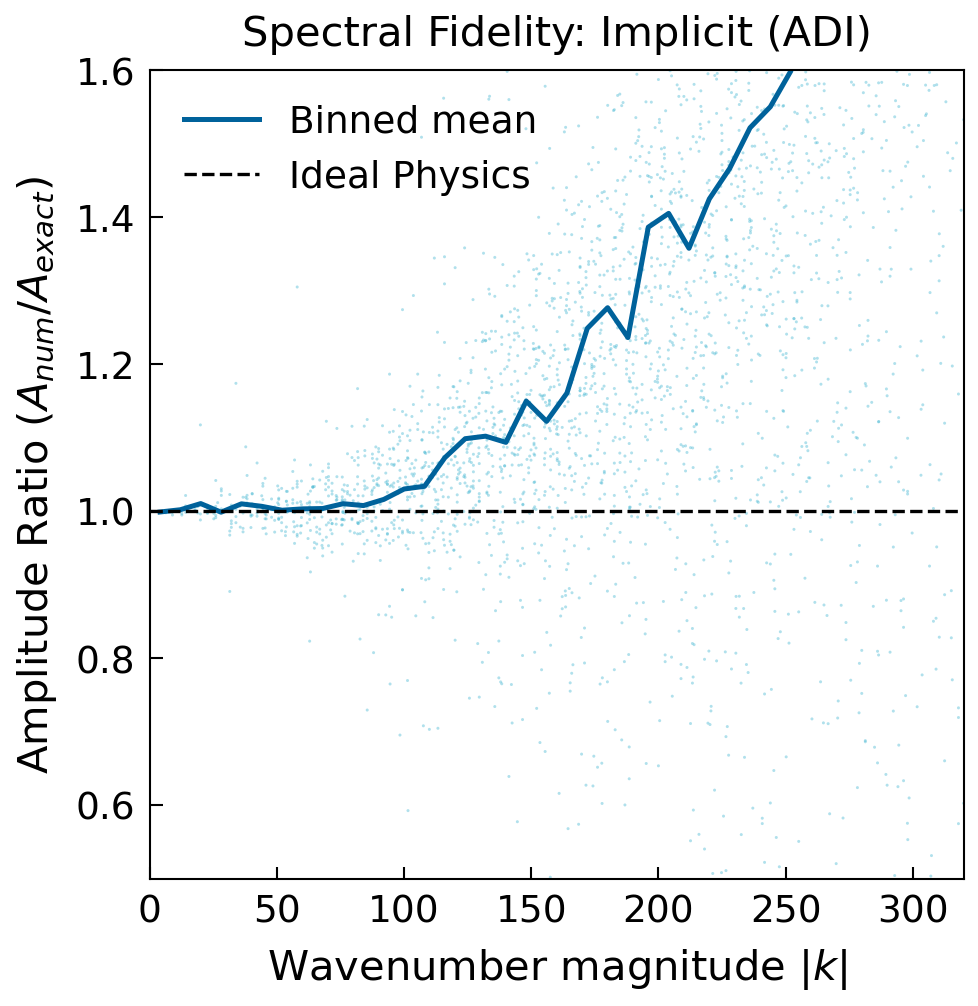

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import factorized
from scipy.fftpack import fftn, fftshift, fftfreq

style_rcParams = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.figsize': (3.5, 3.5),
    'figure.dpi': 300,
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.0,
    'lines.markersize': 3,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'legend.frameon': False,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'mathtext.fontset': 'dejavusans'
}
plt.rcParams.update(style_rcParams)

N = 100
L = 1.0
h = L / N
alpha = 1.0
t_final = 0.00005

np.random.seed(42)
U0 = np.random.randn(N, N)


def solve_implicit_adi(U_initial, dt, steps, alpha, h):
    u = np.copy(U_initial)
    N_grid = u.shape[0]
    k = alpha * dt / (2 * h**2)
    
    diag_main = (1 + 2*k) * np.ones(N_grid)
    diag_main[0] = 1 + k
    diag_main[-1] = 1 + k
    
    A_sparse = diags([-k*np.ones(N_grid-1), diag_main, -k*np.ones(N_grid-1)], 
                     [-1, 0, 1], format='csc')
    solve_A = factorized(A_sparse)
    
    for _ in range(steps):
        u_padded = np.pad(u, 1, mode='edge')
        RHS1 = u + k * (u_padded[1:-1, 0:-2] - 2.0*u + u_padded[1:-1, 2:])
        u_star = solve_A(RHS1)
        
        u_star_padded = np.pad(u_star, 1, mode='edge')
        RHS2 = u_star + k * (u_star_padded[0:-2, 1:-1] - 2.0*u_star + u_star_padded[2:, 1:-1])
        u = solve_A(RHS2.T).T
    
    return u


def get_exact_spectrum(U0, t, alpha, N, L):
    fft_0 = fftn(U0)
    kx = fftfreq(N, d=L/N) * 2 * np.pi
    KX, KY = np.meshgrid(kx, kx, indexing='ij')
    propagator = np.exp(-alpha * (KX**2 + KY**2) * t)
    return fft_0 * propagator


def run_analysis():
    dt_cfl = h**2 / (4 * alpha)
    dt = dt_cfl * 2.0
    steps = max(1, int(t_final / dt))
    actual_t = dt * steps
    
    U_num = solve_implicit_adi(U0, dt, steps, alpha, h)
    
    fft_exact = get_exact_spectrum(U0, actual_t, alpha, N, L)
    fft_num = fftn(U_num)
    
    mag_exact = fftshift(np.abs(fft_exact))
    mag_num = fftshift(np.abs(fft_num))
    
    kx = fftshift(fftfreq(N, d=L/N)) * 2 * np.pi
    KX, KY = np.meshgrid(kx, kx)
    K_mag = np.sqrt(KX**2 + KY**2)
    
    mask = mag_exact > 1e-15
    ratio = np.full_like(mag_num, np.nan)
    ratio[mask] = mag_num[mask] / mag_exact[mask]
    
    k_flat = K_mag.flatten()
    r_flat = ratio.flatten()
    valid = ~np.isnan(r_flat) & (r_flat < 3) & (r_flat > 0)
    k_v = k_flat[valid]
    r_v = r_flat[valid]
    
    n_bins = 40
    k_max = min(320, k_v.max() * 1.1)
    bin_edges = np.linspace(0, k_max, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
    bin_means = []
    for i in range(n_bins):
        in_bin = (k_v >= bin_edges[i]) & (k_v < bin_edges[i+1])
        if np.sum(in_bin) > 3:
            bin_means.append(np.mean(r_v[in_bin]))
        else:
            bin_means.append(np.nan)
    bin_means = np.array(bin_means)
    
    plt.figure()
    
    plt.scatter(k_v, r_v, s=0.5, alpha=0.25, c='#4DBBD5', edgecolors='none', rasterized=True)
    
    valid_bins = ~np.isnan(bin_means)
    plt.plot(bin_centers[valid_bins], bin_means[valid_bins], '-', color='#00629B', 
             linewidth=1.2, label='Binned mean')
    
    plt.axhline(1.0, color='k', linestyle='--', linewidth=0.8, label='Ideal Physics')
    
    plt.xlabel(r'Wavenumber magnitude $|k|$')
    plt.ylabel(r'Amplitude Ratio ($A_{num}/A_{exact}$)')
    plt.title('Spectral Fidelity: Implicit (ADI)')
    
    plt.xlim(0, 320)
    plt.ylim(0.5, 1.6)
    plt.legend(loc='upper left')
    
    plt.savefig('spectrum_implicit_full.png', dpi=300)
    plt.show()


if __name__ == '__main__':
    run_analysis()

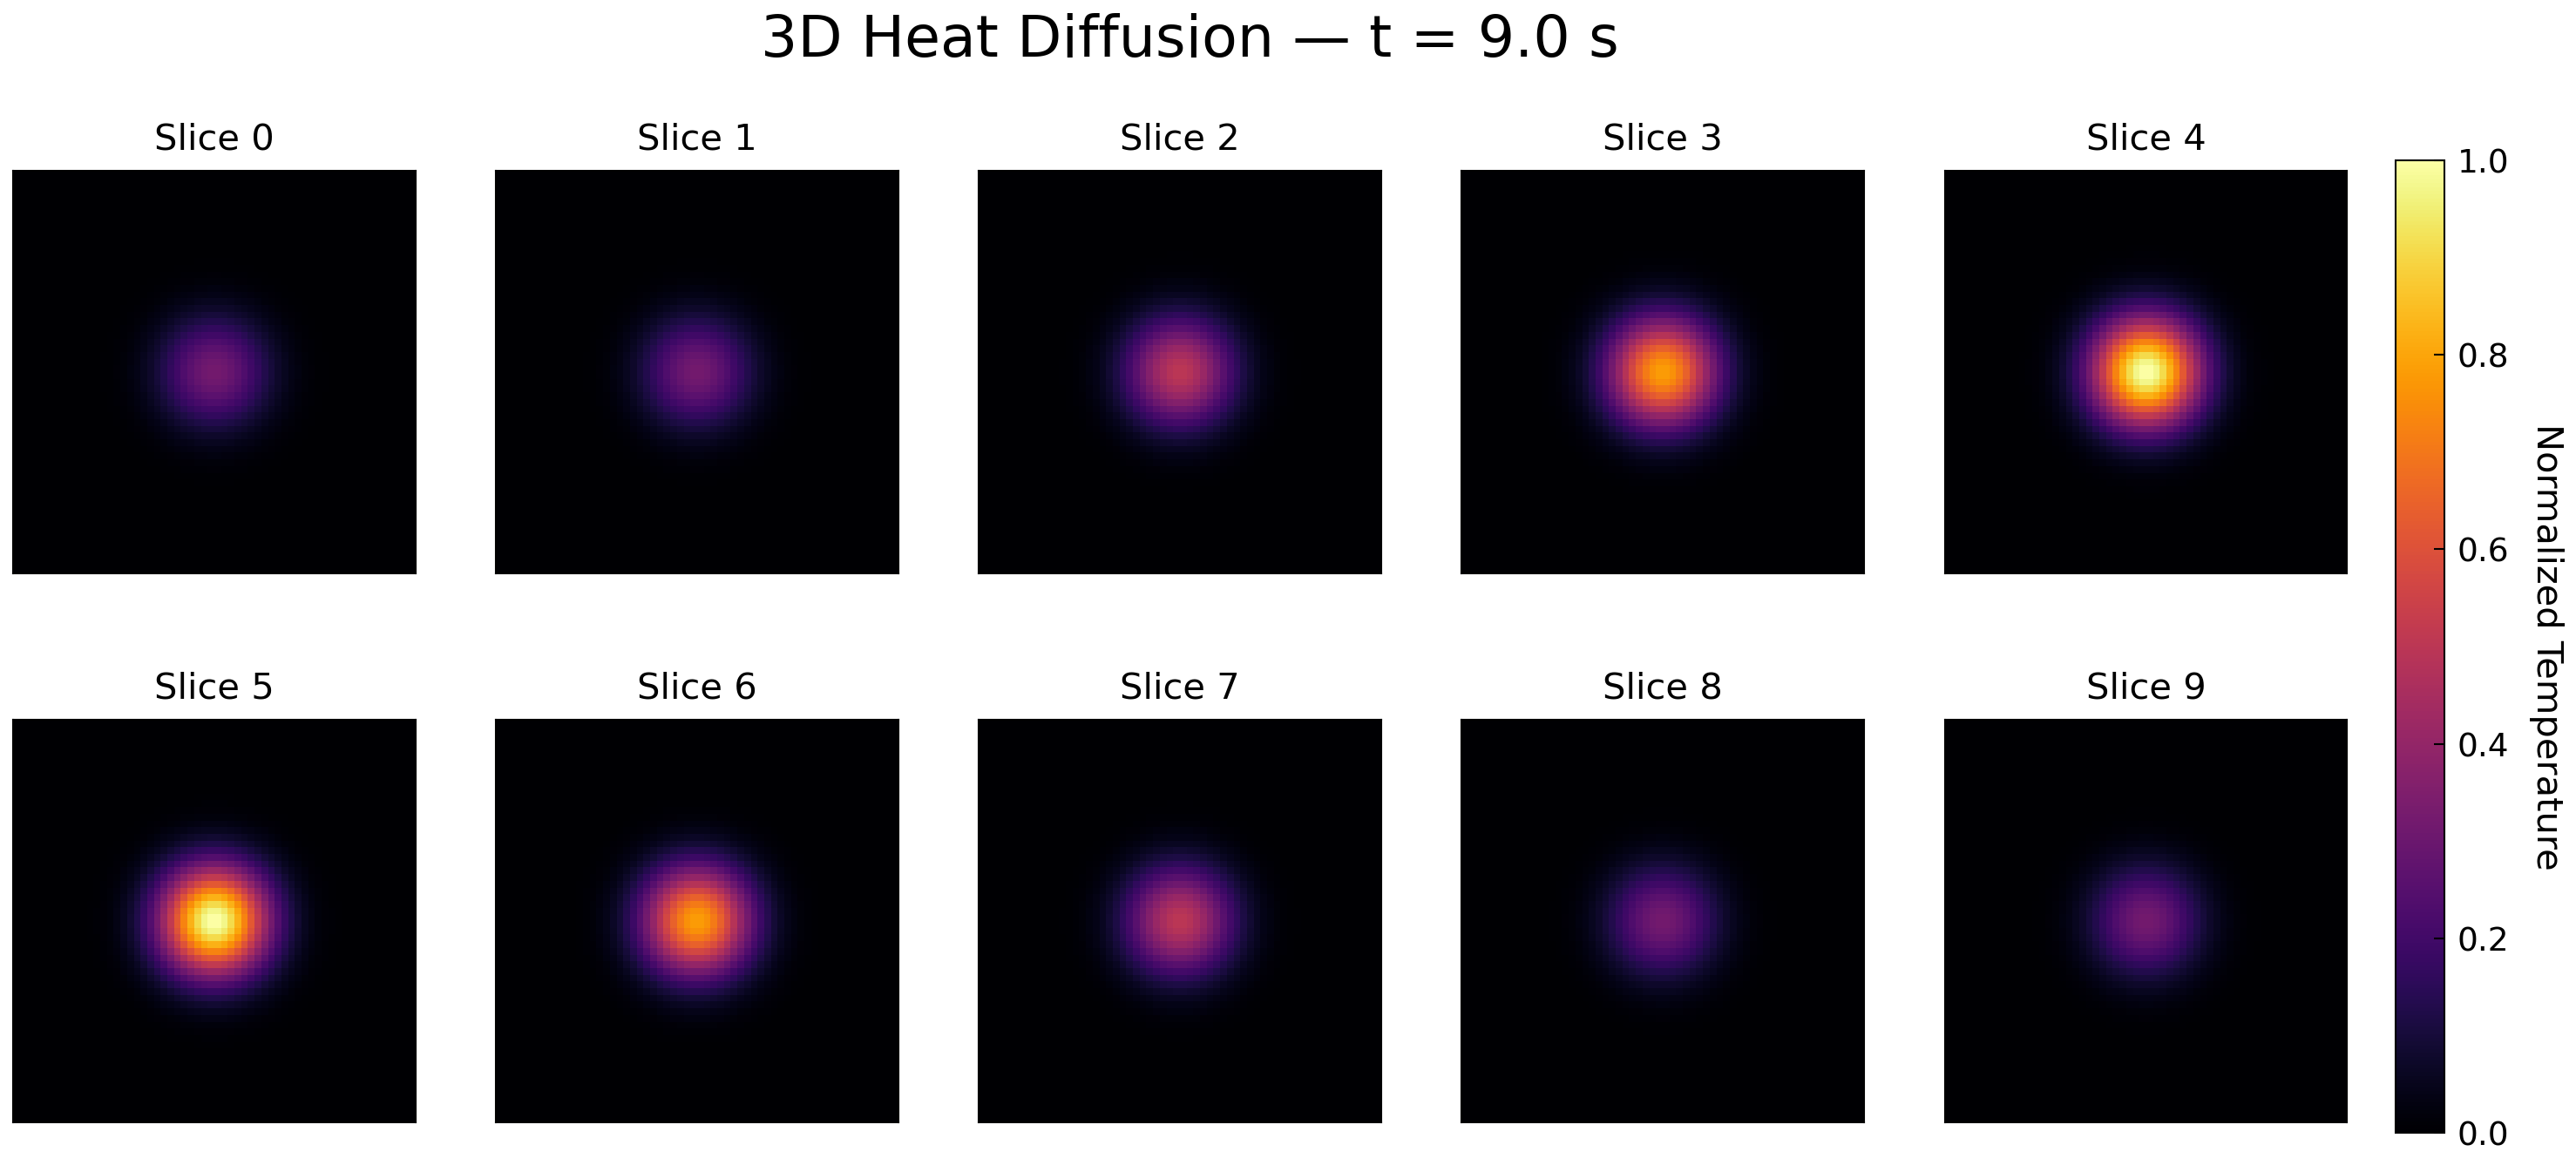

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import os

nx = ny = 60
nz = 10

alpha = 0.2
dx = dy = dz = 1
dt = 0.05

t_target = 9.0
steps = int(t_target / dt)

rows, cols = 2, 5

x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
z = np.linspace(-1, 1, nz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

sigma = 0.18
u = 10.0 * np.exp(-(X**2 + Y**2 + Z**2) / (2 * sigma**2))


def laplacian(u):
    lap = np.zeros_like(u)

    lap[1:-1,1:-1,1:-1] = (
        u[2:,1:-1,1:-1] + u[:-2,1:-1,1:-1] +
        u[1:-1,2:,1:-1] + u[1:-1,:-2,1:-1] +
        u[1:-1,1:-1,2:] + u[1:-1,1:-1,:-2]
        - 6 * u[1:-1,1:-1,1:-1]
    )

    # Neumann boundaries
    lap[0,:,:]  = lap[1,:,:]
    lap[-1,:,:] = lap[-2,:,:]
    lap[:,0,:]  = lap[:,1,:]
    lap[:,-1,:] = lap[:,-2,:]
    lap[:,:,0]  = lap[:,:,1]
    lap[:,:,-1] = lap[:,:,-2]

    return lap


# Time integration
for step in range(steps):
    u = u + dt * alpha * laplacian(u)


# ---- Plot at t = 9 s ----
fig, axes = plt.subplots(rows, cols, figsize=(12, 5))
axes = axes.flatten()

u_norm = (u - u.min()) / (u.max() - u.min() + 1e-8)

for i in range(nz):
    ax = axes[i]
    img = ax.imshow(
        u_norm[:, :, i],
        cmap="inferno",
        origin="lower",
        vmin=0,
        vmax=1
    )
    ax.set_title(f"Slice {i}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

cbar = fig.colorbar(img, ax=axes.tolist(), fraction=0.02, pad=0.02)
cbar.set_label("Normalized Temperature", rotation=270, labelpad=15)

fig.suptitle("3D Heat Diffusion — t = 9.0 s", fontsize=16)

os.makedirs("output", exist_ok=True)
fig.savefig("output/heat_diffusion_t9.png", dpi=140, bbox_inches="tight")
plt.show()